In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import json
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/data/processed/Dinner_feature_2024_2025.csv", parse_dates=["Date"])
df_clean = df.dropna().reset_index(drop=True)
df_sorted = df_clean.sort_values("Date").reset_index(drop=True)

In [4]:
feature_cols = [c for c in df_clean.columns if c not in ["Date", "Target_Headcount", "Category", "Notes", "DayOfWeek"]]

In [5]:
with open("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/dinner/best_params.json") as f:
    best = json.load(f)

xgb_params = best["xgboost"]
lgbm_params = best["lightgbm"]
cb_params = best["catboost"]

In [6]:
fold_windows = [
    ("2024-01-01", "2024-12-31", "2025-01-01", "2025-03-01"),
    ("2024-01-01", "2025-03-01", "2025-03-01", "2025-05-01"),
    ("2024-01-01", "2025-05-01", "2025-05-01", "2025-07-01"),
    ("2024-01-01", "2025-07-01", "2025-07-01", "2025-09-01"),
    ("2024-01-01", "2025-09-01", "2025-09-01", "2025-11-01"),
    ("2024-01-01", "2025-11-01", "2025-11-01", "2026-01-01"),
]

In [7]:
residuals = []

for train_st, train_end, val_st, val_end in fold_windows:
    
    train_fold = df_sorted[(df_sorted["Date"] >= train_st) & (df_sorted["Date"] < train_end)]
    val_fold = df_sorted[(df_sorted["Date"] >= val_st) & (df_sorted["Date"] < val_end)]

    model1 = XGBRegressor(**xgb_params)
    model2 = LGBMRegressor(**lgbm_params)
    model3 = CatBoostRegressor(**cb_params)
    for model in [model1, model2, model3]:
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])

    xgb_pred = model1.predict(val_fold[feature_cols])
    lgbm_pred = model2.predict(val_fold[feature_cols])
    cb_pred = model3.predict(val_fold[feature_cols])
    pred = (model1.predict(val_fold[feature_cols]) + model2.predict(val_fold[feature_cols]) + model3.predict(val_fold[feature_cols])) / 3

    fold_df = val_fold.copy()
    
    fold_df["Predictions"] = pred
    fold_df["xgb_pred"] = xgb_pred
    fold_df["lgbm_pred"] = lgbm_pred
    fold_df["cb_pred"] = cb_pred
    
    fold_df["Residual"] = fold_df["Target_Headcount"] - pred
    fold_df["xgb_Residual"] = fold_df["Target_Headcount"] - xgb_pred
    fold_df["lgbm_Residual"] = fold_df["Target_Headcount"] - lgbm_pred
    fold_df["cb_Residual"] = fold_df["Target_Headcount"] - cb_pred
    
    fold_df["AbsResidual"] = np.abs(fold_df["Residual"])
    fold_df["xgb_AbsResidual"] = np.abs(fold_df["xgb_Residual"])
    fold_df["lgbm_AbsResidual"] = np.abs(fold_df["lgbm_Residual"])
    fold_df["cb_AbsResidual"] = np.abs(fold_df["cb_Residual"])
    
    fold_df["PercentResidual"] = fold_df["AbsResidual"] * 100 / fold_df["Target_Headcount"]

    residuals.append(fold_df)

residual_df = pd.concat(residuals).sort_values("Date").reset_index(drop=True)
print(f"Total rows: {len(residual_df)}")
print(f"Date range: {residual_df['Date'].min()} to {residual_df['Date'].max()}")
residual_df.head()

Total rows: 345
Date range: 2025-01-21 00:00:00 to 2025-12-31 00:00:00


,Date,DayOfWeek,DayOfMonth,Month,Is_Start_Of_Month,Is_End_Of_Month,Is_Weekend,Is_Holiday,Is_Vacation,Is_Exam_Period,...,cb_pred,Residual,xgb_Residual,lgbm_Residual,cb_Residual,AbsResidual,xgb_AbsResidual,lgbm_AbsResidual,cb_AbsResidual,PercentResidual
0,2025-01-21,Tuesday,21,1,0,0,0,0,0,0,...,340.533265,57.989967,43.509796,28.993371,101.466735,57.989967,43.509796,28.993371,101.466735,13.119902
1,2025-01-22,Wednesday,22,1,0,0,0,0,0,0,...,434.637346,99.063020,92.416382,54.410024,150.362654,99.063020,92.416382,54.410024,150.362654,16.933850
2,2025-01-23,Thursday,23,1,0,0,0,0,0,0,...,352.197303,-17.931094,-41.582764,-12.013215,-0.197303,17.931094,41.582764,12.013215,0.197303,5.094061
3,2025-01-24,Friday,24,1,0,1,0,0,0,0,...,400.345866,42.532411,37.151337,53.791763,36.654134,42.532411,37.151337,53.791763,36.654134,9.732817
4,2025-01-25,Saturday,25,1,0,1,1,0,0,0,...,171.350362,22.366660,15.933899,34.516443,16.649638,22.366660,15.933899,34.516443,16.649638,11.897160


In [8]:
print("=== Absolute Residual Distribution ===")
print(residual_df["AbsResidual"].describe())
print()
print("Median:", residual_df["AbsResidual"].median())
print(f"90th percentile: {residual_df['AbsResidual'].quantile(0.90):.1f}")
print(f"95th percentile: {residual_df['AbsResidual'].quantile(0.95):.1f}")
print(f"Worst single miss: {residual_df['AbsResidual'].max():.1f}")
print()

print("=== Absolute Residual XGB Distribution ===")
print(residual_df["xgb_AbsResidual"].describe())
print()
print("Median:", residual_df["xgb_AbsResidual"].median())
print(f"90th percentile: {residual_df['xgb_AbsResidual'].quantile(0.90):.1f}")
print(f"95th percentile: {residual_df['xgb_AbsResidual'].quantile(0.95):.1f}")
print(f"Worst single miss: {residual_df['xgb_AbsResidual'].max():.1f}")
print()

print("=== Absolute Residual LGBM Distribution ===")
print(residual_df["lgbm_AbsResidual"].describe())
print()
print("Median:", residual_df["lgbm_AbsResidual"].median())
print(f"90th percentile: {residual_df['lgbm_AbsResidual'].quantile(0.90):.1f}")
print(f"95th percentile: {residual_df['lgbm_AbsResidual'].quantile(0.95):.1f}")
print(f"Worst single miss: {residual_df['lgbm_AbsResidual'].max():.1f}")
print()

print("=== Absolute Residual CB Distribution ===")
print(residual_df["cb_AbsResidual"].describe())
print()
print("Median:", residual_df["cb_AbsResidual"].median())
print(f"90th percentile: {residual_df['cb_AbsResidual'].quantile(0.90):.1f}")
print(f"95th percentile: {residual_df['cb_AbsResidual'].quantile(0.95):.1f}")
print(f"Worst single miss: {residual_df['cb_AbsResidual'].max():.1f}")
print()

print("=== Signed Residual (bias check) ===")
print(f"Mean signed residual: {residual_df['Residual'].mean():.2f}")
print(f"  (positive = model tends to underpredict overall, negative = overpredict)")
print()
print(f"Underpredicted days (Residual > 0): {(residual_df['Residual'] > 0).sum()} / {len(residual_df)}")
print(f"Overpredicted days (Residual < 0): {(residual_df['Residual'] < 0).sum()} / {len(residual_df)}")
print()

print("=== Signed Residual XGB (bias check) ===")
print(f"Mean signed residual: {residual_df['xgb_Residual'].mean():.2f}")
print(f"  (positive = model tends to underpredict overall, negative = overpredict)")
print()
print(f"Underpredicted days (Residual > 0): {(residual_df['xgb_Residual'] > 0).sum()} / {len(residual_df)}")
print(f"Overpredicted days (Residual < 0): {(residual_df['xgb_Residual'] < 0).sum()} / {len(residual_df)}")
print()

print("=== Signed Residual LGBM (bias check) ===")
print(f"Mean signed residual: {residual_df['lgbm_Residual'].mean():.2f}")
print(f"  (positive = model tends to underpredict overall, negative = overpredict)")
print()
print(f"Underpredicted days (Residual > 0): {(residual_df['lgbm_Residual'] > 0).sum()} / {len(residual_df)}")
print(f"Overpredicted days (Residual < 0): {(residual_df['lgbm_Residual'] < 0).sum()} / {len(residual_df)}")
print()

print("=== Signed Residual CB (bias check) ===")
print(f"Mean signed residual: {residual_df['cb_Residual'].mean():.2f}")
print(f"  (positive = model tends to underpredict overall, negative = overpredict)")
print()
print(f"Underpredicted days (Residual > 0): {(residual_df['cb_Residual'] > 0).sum()} / {len(residual_df)}")
print(f"Overpredicted days (Residual < 0): {(residual_df['cb_Residual'] < 0).sum()} / {len(residual_df)}")
print()

=== Absolute Residual Distribution ===
count    345.000000
mean      51.012334
std       42.227674
min        0.448203
25%       18.521200
50%       40.910462
75%       67.709154
max      255.261824
Name: AbsResidual, dtype: float64

Median: 40.910461841560206
90th percentile: 106.8
95th percentile: 135.9
Worst single miss: 255.3

=== Absolute Residual XGB Distribution ===
count    345.000000
mean      51.578831
std       42.954291
min        0.151276
25%       18.977570
50%       41.582764
75%       69.917725
max      264.946136
Name: xgb_AbsResidual, dtype: float64

Median: 41.582763671875
90th percentile: 105.0
95th percentile: 138.1
Worst single miss: 264.9

=== Absolute Residual LGBM Distribution ===
count    345.000000
mean      51.084080
std       43.728469
min        0.078206
25%       18.758995
50%       39.809005
75%       71.873418
max      262.068444
Name: lgbm_AbsResidual, dtype: float64

Median: 39.809005192541406
90th percentile: 111.1
95th percentile: 135.1
Worst single

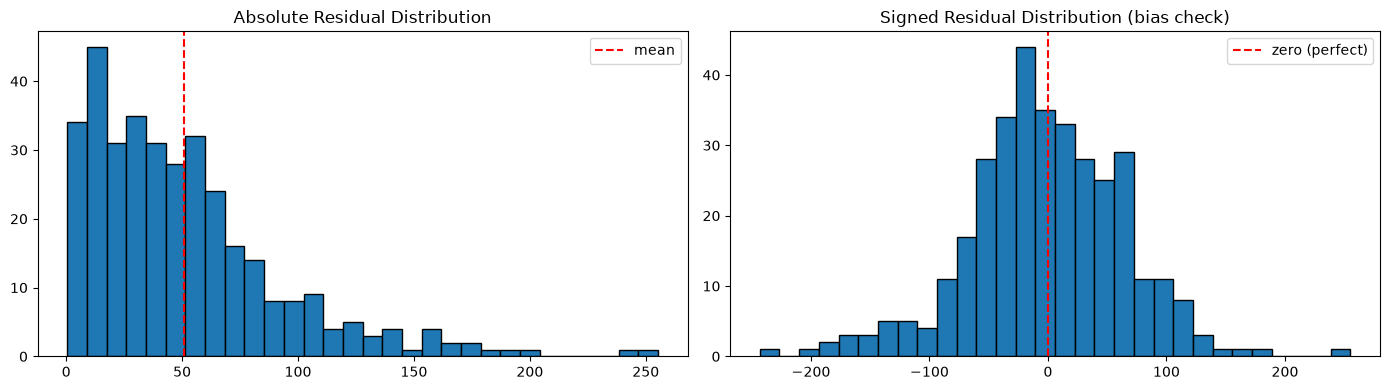

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(residual_df["AbsResidual"], bins=30, edgecolor='black')
axes[0].axvline(residual_df["AbsResidual"].mean(), color='red', linestyle='--', label='mean')
axes[0].set_title("Absolute Residual Distribution")
axes[0].legend()

axes[1].hist(residual_df["Residual"], bins=30, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', label='zero (perfect)')
axes[1].set_title("Signed Residual Distribution (bias check)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
threshold_abs = residual_df["AbsResidual"].quantile(0.90)
worst_by_abs = residual_df[residual_df["AbsResidual"] >= threshold_abs].sort_values("AbsResidual", ascending=False)

print(f"Days at/above 90th percentile ({threshold_abs:.1f} AbsResidual): {len(worst_by_abs)}")
print()
cols_to_show = ["Date", "Target_Headcount", "Predictions", "Residual", "AbsResidual", "PercentResidual",
                 "DayOfWeek", "Is_Weekend", "Is_Exam_Period", "Is_Fest", "Is_Vacation", "Is_Holiday"]
worst_by_abs[cols_to_show]

Days at/above 90th percentile (106.8 AbsResidual): 35



,Date,Target_Headcount,Predictions,Residual,AbsResidual,PercentResidual,DayOfWeek,Is_Weekend,Is_Exam_Period,Is_Fest,Is_Vacation,Is_Holiday
175,2025-07-15,459.0,203.738176,255.261824,255.261824,55.612598,Tuesday,0,0,0,1,0
101,2025-05-02,103.0,346.180284,-243.180284,243.180284,236.097363,Friday,0,1,0,0,0
289,2025-11-06,83.0,287.017922,-204.017922,204.017922,245.804725,Thursday,0,0,0,0,0
253,2025-10-01,272.0,463.686280,-191.686280,191.686280,70.472897,Wednesday,0,0,0,0,0
315,2025-12-02,146.0,329.125938,-183.125938,183.125938,125.428725,Tuesday,0,1,0,0,0
241,2025-09-19,540.0,361.315084,178.684916,178.684916,33.089799,Friday,0,0,0,0,0
269,2025-10-17,132.0,302.445254,-170.445254,170.445254,129.125192,Friday,0,0,0,0,0
8,2025-01-29,346.0,512.165286,-166.165286,166.165286,48.024649,Wednesday,0,0,0,0,0
314,2025-12-01,168.0,330.131867,-162.131867,162.131867,96.507064,Monday,0,1,0,0,0
296,2025-11-13,455.0,294.181652,160.818348,160.818348,35.344692,Thursday,0,0,0,0,0


In [11]:

exam_weekday = residual_df[(residual_df["Is_Exam_Period"]==1) & (residual_df["DayOfWeek"]!="Sunday")]
exam_sunday  = residual_df[(residual_df["Is_Exam_Period"]==1) & (residual_df["DayOfWeek"]=="Sunday")]
non_exam     = residual_df[residual_df["Is_Exam_Period"]==0]
print("Exam, non-Sunday:", exam_weekday["AbsResidual"].mean(), "bias:", exam_weekday["Residual"].mean(), "n=", len(exam_weekday))
print("Exam, Sunday:", exam_sunday["AbsResidual"].mean(), "bias:", exam_sunday["Residual"].mean(), "n=", len(exam_sunday))
print("Non-exam:", non_exam["AbsResidual"].mean(), "bias:", non_exam["Residual"].mean(), "n=", len(non_exam))

sun_noexam = residual_df[(residual_df["DayOfWeek"]=="Sunday") & (residual_df["Is_Exam_Period"]==0)]
other_noexam = residual_df[(residual_df["DayOfWeek"]!="Sunday") & (residual_df["Is_Exam_Period"]==0)]
print("\nSunday, non-exam:", sun_noexam["AbsResidual"].mean(), "bias:", sun_noexam["Residual"].mean(), "n=", len(sun_noexam))
print("Other days, non-exam:", other_noexam["AbsResidual"].mean(), "bias:", other_noexam["Residual"].mean(), "n=", len(other_noexam))

Exam, non-Sunday: 80.08648398440025 bias: -74.88563778772898 n= 29
Exam, Sunday: 93.74729494367344 bias: 41.99846236198145 n= 7
Non-exam: 47.31558615511448 bias: 3.450685220191997 n= 309

Sunday, non-exam: 57.155518381234664 bias: 36.044729676233956 n= 42
Other days, non-exam: 45.76773164763489 bias: -1.6764678403089814 n= 267


In [12]:
bucket_columns = ["DayOfWeek", "Is_Weekend", "Is_Exam_Period", "Is_Fest", "Is_Vacation", "Is_Holiday", "Month"]

for column in bucket_columns:

    print()
    print(f"{column}")
    print()

    summary = (residual_df.groupby(column).agg(
        Count=("Residual", "count"), 
        Mean_Abs_Residual=("AbsResidual", "mean"),
        Median_Abs_Residual=("AbsResidual", "median"),
        Mean_Bias=("Residual", "mean"),
    ).round(2))

    print(summary)
    print()
    print("-" * 70)


DayOfWeek

           Count  Mean_Abs_Residual  Median_Abs_Residual  Mean_Bias
DayOfWeek                                                          
Friday        49              49.91                39.55      -4.57
Monday        49              46.91                33.54      -4.74
Saturday      49              32.42                29.39     -26.41
Sunday        49              62.38                57.53      36.90
Thursday      49              53.32                42.99     -10.84
Tuesday       50              54.13                47.70      -1.80
Wednesday     50              57.80                49.71      -4.96

----------------------------------------------------------------------

Is_Weekend

            Count  Mean_Abs_Residual  Median_Abs_Residual  Mean_Bias
Is_Weekend                                                          
0             247              52.45                43.42      -5.37
1              98              47.40                36.82       5.24

--------------

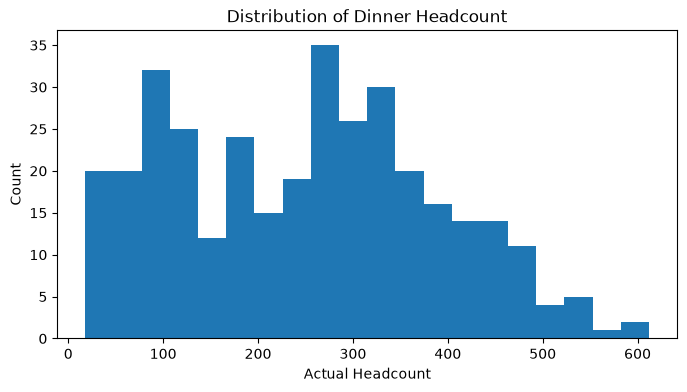

In [13]:
plt.figure(figsize=(8,4))
plt.hist(residual_df["Target_Headcount"], bins=20)
plt.xlabel("Actual Headcount")
plt.ylabel("Count")
plt.title("Distribution of Dinner Headcount")
plt.show()

In [14]:
residual_df["AttendanceBucket"] = pd.cut(
    residual_df["Target_Headcount"],
    bins=[0,100,200,300,400,500,600],
    include_lowest=True
)

attendance_summary = (
    residual_df
    .groupby("AttendanceBucket")
    .agg(
        Count=("Residual", "count"),
        Mean_Abs_Residual=("AbsResidual", "mean"),
        Median_Abs_Residual=("AbsResidual", "median"),
        Mean_Bias=("Residual", "mean"),
    )
    .round(2)
)

print(attendance_summary)

                  Count  Mean_Abs_Residual  Median_Abs_Residual  Mean_Bias
AttendanceBucket                                                          
(-0.001, 100.0]      68              42.92                33.52     -37.48
(100.0, 200.0]       68              49.00                28.72     -32.77
(200.0, 300.0]       78              45.30                38.63      -9.21
(300.0, 400.0]       78              48.93                48.24      17.44
(400.0, 500.0]       41              79.56                74.86      63.99
(500.0, 600.0]       11              65.36                55.41      61.97


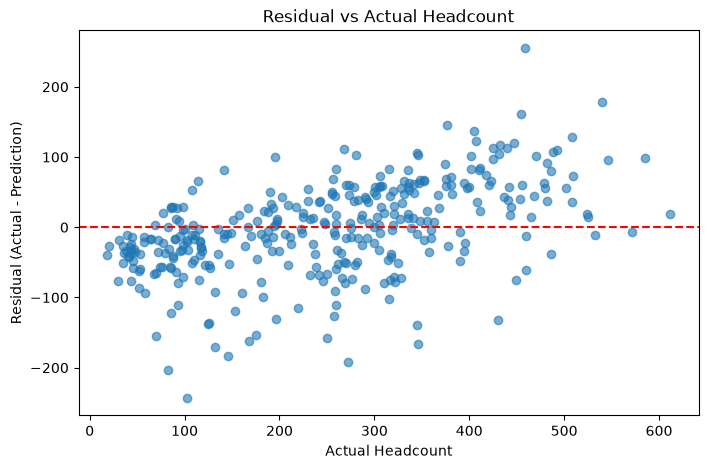

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    residual_df["Target_Headcount"],
    residual_df["Residual"],
    alpha=0.6
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Actual Headcount")
plt.ylabel("Residual (Actual - Prediction)")
plt.title("Residual vs Actual Headcount")

plt.show()

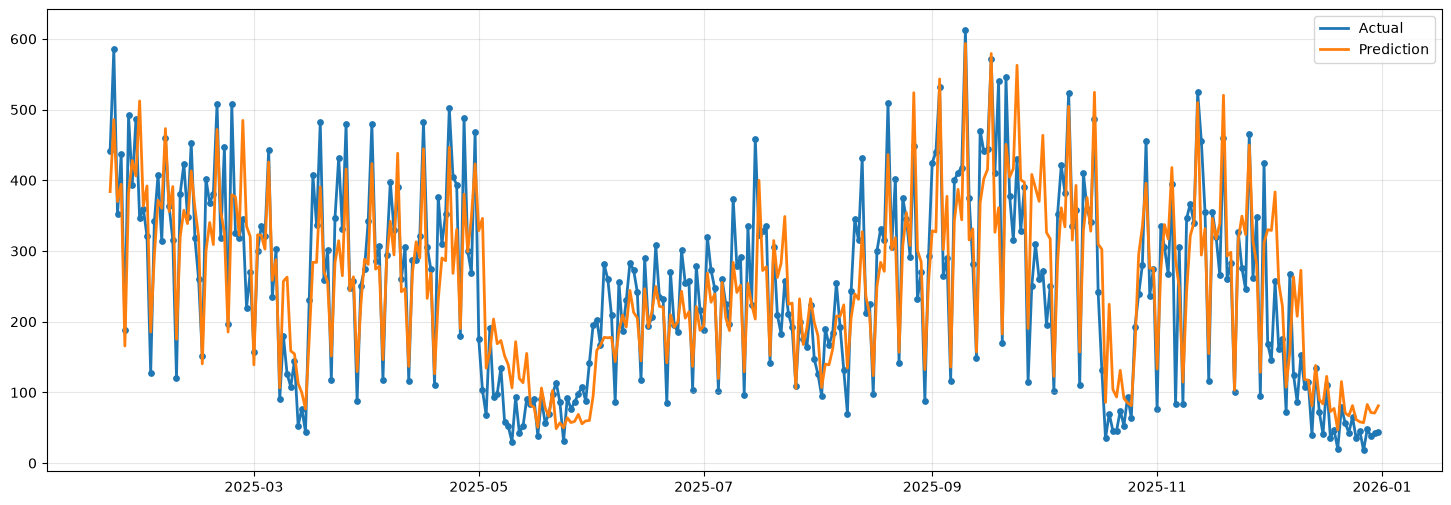

In [16]:
plt.figure(figsize=(18,6))

plt.plot(
    residual_df["Date"],
    residual_df["Target_Headcount"],
    label="Actual",
    linewidth=2
)

plt.plot(
    residual_df["Date"],
    residual_df["Predictions"],
    label="Prediction",
    linewidth=2
)

plt.scatter(
    residual_df["Date"],
    residual_df["Target_Headcount"],
    s=15
)

plt.legend()
plt.grid(alpha=0.3)

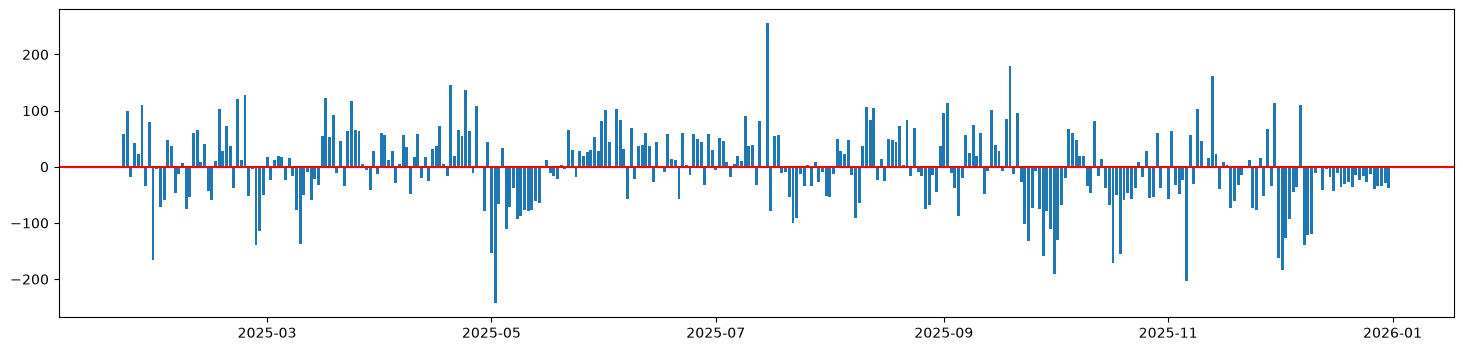

In [17]:
plt.figure(figsize=(18,4))

plt.bar(
    residual_df["Date"],
    residual_df["Residual"]
)

plt.axhline(0,color="red")

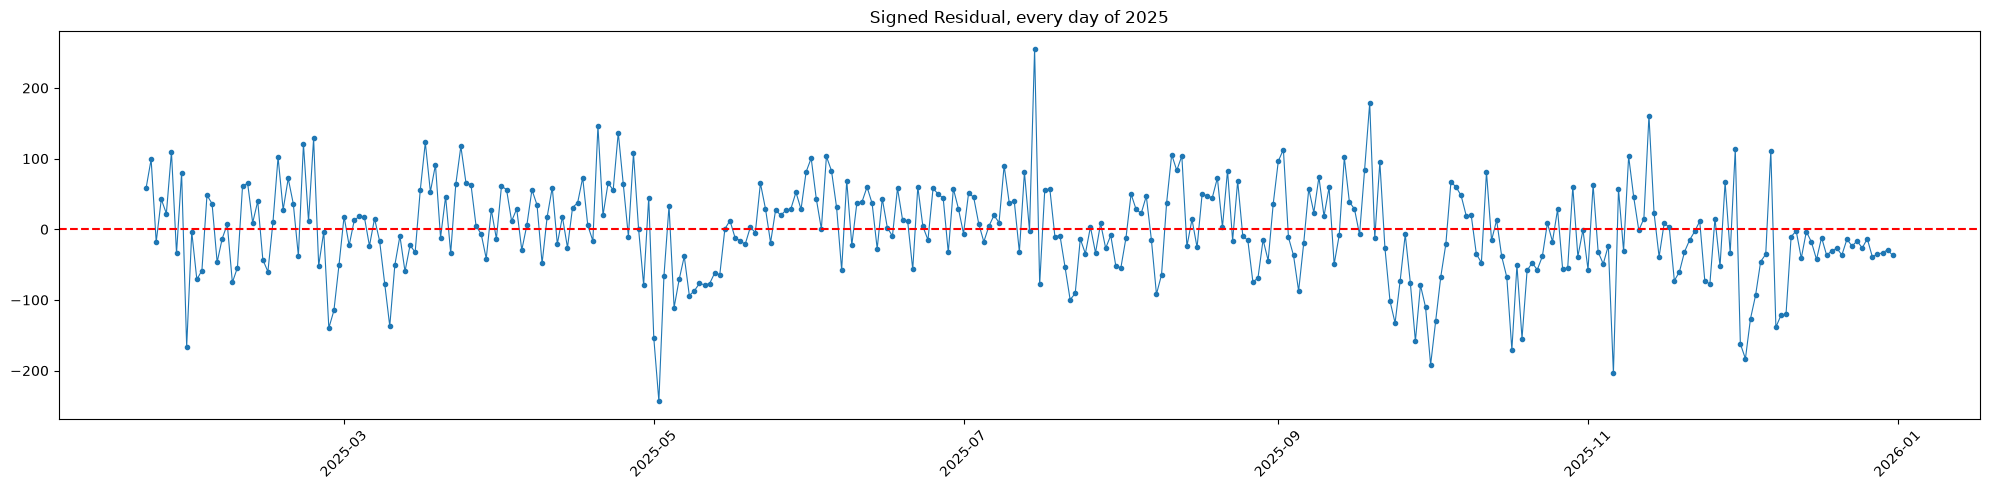

In [18]:
fig, ax = plt.subplots(figsize=(20, 5))
resid_sorted = residual_df.sort_values("Date")
ax.plot(resid_sorted["Date"], resid_sorted["Residual"], marker='o', markersize=3, linewidth=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_title("Signed Residual, every day of 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

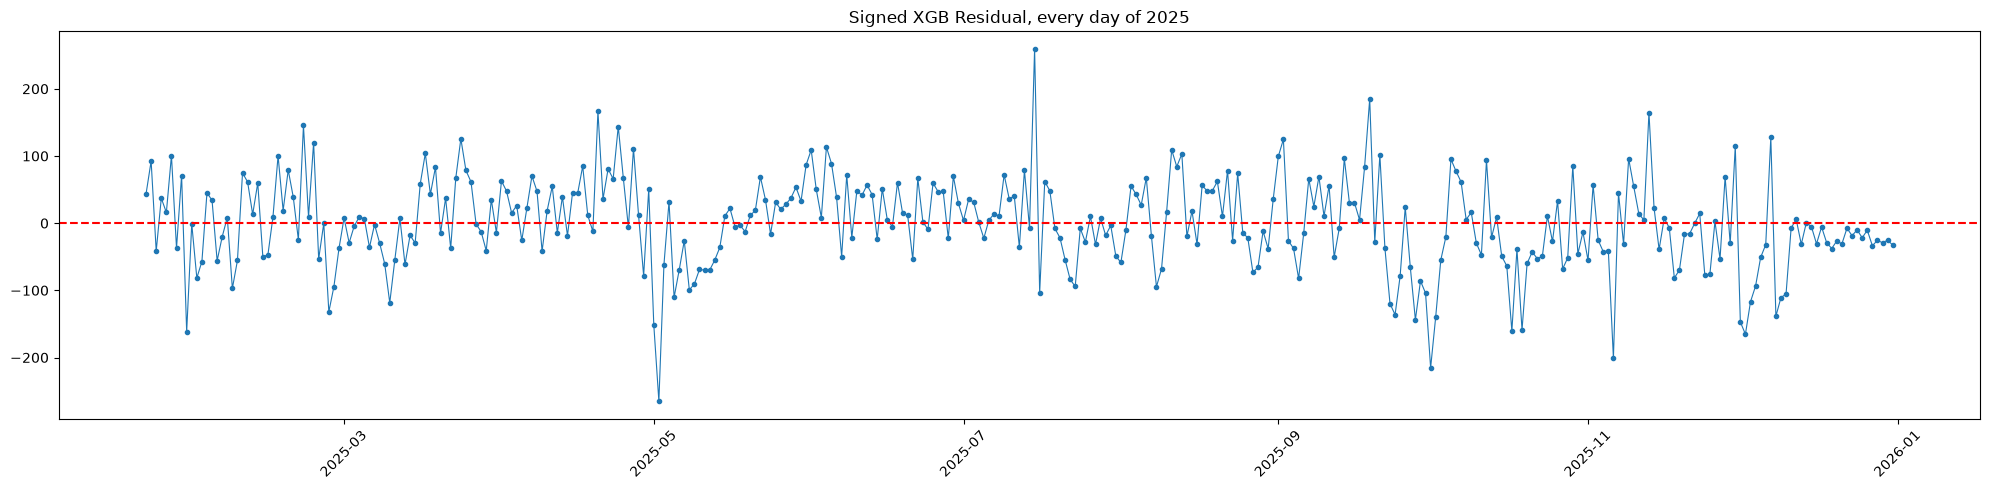

In [19]:
fig, ax = plt.subplots(figsize=(20, 5))
resid_sorted = residual_df.sort_values("Date")
ax.plot(resid_sorted["Date"], resid_sorted["xgb_Residual"], marker='o', markersize=3, linewidth=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_title("Signed XGB Residual, every day of 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

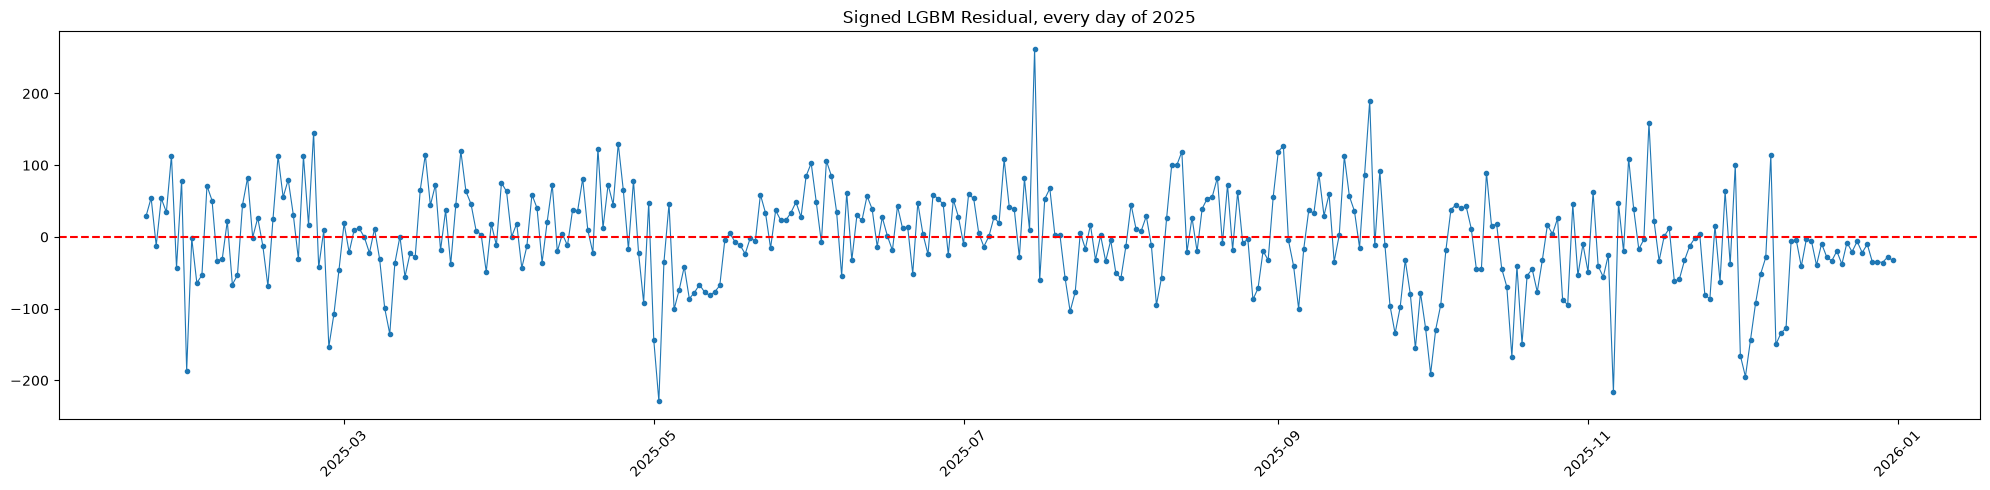

In [20]:
fig, ax = plt.subplots(figsize=(20, 5))
resid_sorted = residual_df.sort_values("Date")
ax.plot(resid_sorted["Date"], resid_sorted["lgbm_Residual"], marker='o', markersize=3, linewidth=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_title("Signed LGBM Residual, every day of 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

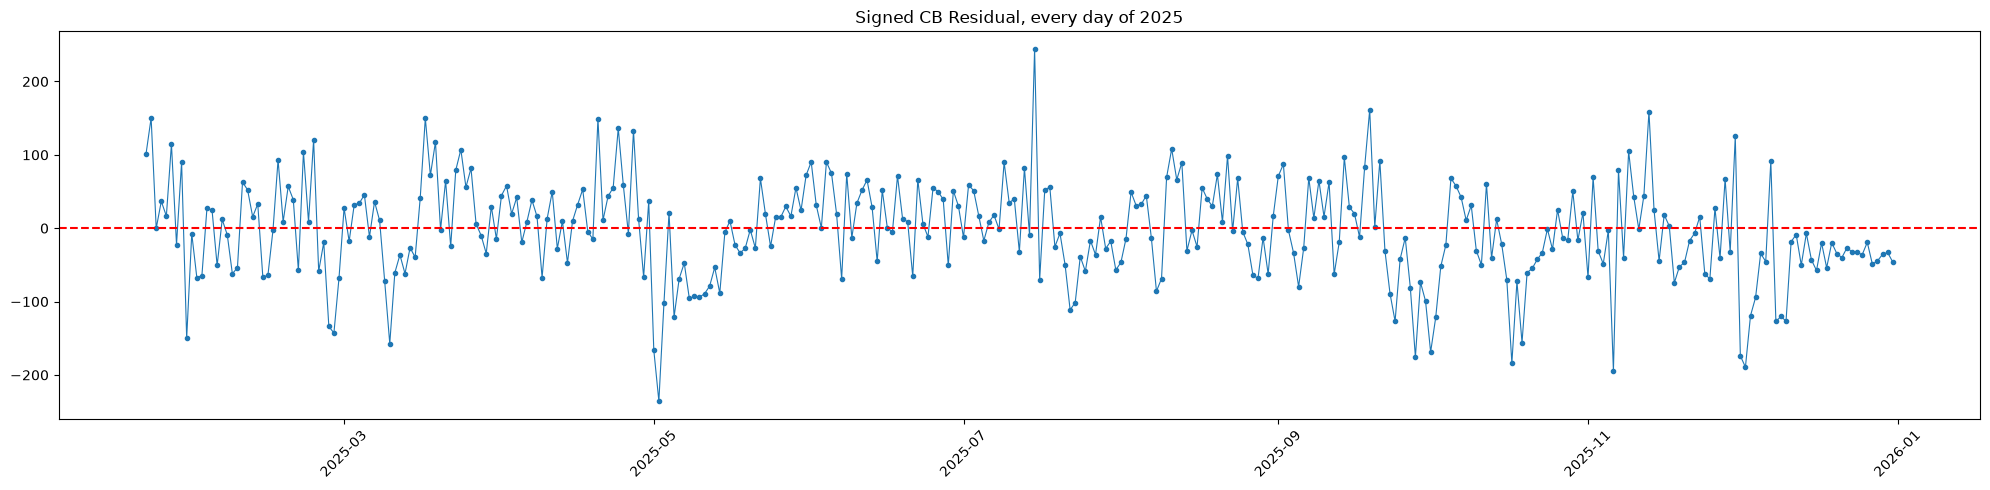

In [21]:
fig, ax = plt.subplots(figsize=(20, 5))
resid_sorted = residual_df.sort_values("Date")
ax.plot(resid_sorted["Date"], resid_sorted["cb_Residual"], marker='o', markersize=3, linewidth=0.8)
ax.axhline(0, color='red', linestyle='--')
ax.set_title("Signed CB Residual, every day of 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
sat = residual_df[residual_df["DayOfWeek"] == "Saturday"]
sun = residual_df[residual_df["DayOfWeek"] == "Sunday"]
overall_avg = residual_df["Target_Headcount"].mean()

print("Step 1: Do Sat/Sun differ in average attendance level?")
print(f"Saturday avg actual headcount: {sat['Target_Headcount'].mean():.1f}")
print(f"Sunday avg actual headcount:   {sun['Target_Headcount'].mean():.1f}")
print(f"Overall avg actual headcount:  {overall_avg:.1f}")
print()

print("Step 2: Sat/Sun bias vs other days, WITHIN the same attendance bucket")
for day in ["Saturday", "Sunday"]:
    day_df = residual_df[residual_df["DayOfWeek"] == day]
    for bucket in day_df["AttendanceBucket"].cat.categories:
        day_in_bucket = day_df[day_df["AttendanceBucket"] == bucket]
        others_in_bucket = residual_df[(residual_df["AttendanceBucket"] == bucket) & (residual_df["DayOfWeek"] != day)]
        if len(day_in_bucket) >= 3 and len(others_in_bucket) >= 3:
            print(f"{day}, bucket {bucket}: n={len(day_in_bucket)}, bias={day_in_bucket['Residual'].mean():.1f} "
                  f"| others same bucket: n={len(others_in_bucket)}, bias={others_in_bucket['Residual'].mean():.1f}")

Step 1: Do Sat/Sun differ in average attendance level?
Saturday avg actual headcount: 100.6
Sunday avg actual headcount:   288.7
Overall avg actual headcount:  249.7

Step 2: Sat/Sun bias vs other days, WITHIN the same attendance bucket
Saturday, bucket (-0.001, 100.0]: n=24, bias=-37.1 | others same bucket: n=44, bias=-37.7
Saturday, bucket (100.0, 200.0]: n=25, bias=-16.1 | others same bucket: n=43, bias=-42.5
Sunday, bucket (-0.001, 100.0]: n=6, bias=-48.8 | others same bucket: n=62, bias=-36.4
Sunday, bucket (100.0, 200.0]: n=7, bias=14.0 | others same bucket: n=61, bias=-38.1
Sunday, bucket (200.0, 300.0]: n=15, bias=26.3 | others same bucket: n=63, bias=-17.7
Sunday, bucket (300.0, 400.0]: n=13, bias=59.2 | others same bucket: n=65, bias=9.1
Sunday, bucket (400.0, 500.0]: n=6, bias=102.6 | others same bucket: n=35, bias=57.4


In [26]:
df_vac_sorted = residual_df.sort_values("Date").reset_index(drop=True)
vacation_flag = df_vac_sorted["Is_Vacation"].values
dates = df_vac_sorted["Date"].values

starts, ends = [], []
for i in range(1, len(vacation_flag)):
    if vacation_flag[i] == 1 and vacation_flag[i-1] == 0:
        starts.append(dates[i])
    if vacation_flag[i] == 0 and vacation_flag[i-1] == 1:
        ends.append(dates[i-1])

print(f"Vacation blocks found: {len(starts)} starts, {len(ends)} ends")

pre_vacation_rows = []
for start_date in starts:
    window = residual_df[(residual_df["Date"] >= pd.Timestamp(start_date) - pd.Timedelta(days=5)) &
                          (residual_df["Date"] < pd.Timestamp(start_date))]
    pre_vacation_rows.append(window)
pre_vac_df = pd.concat(pre_vacation_rows) if pre_vacation_rows else pd.DataFrame()

post_vacation_rows = []
for end_date in ends:
    window = residual_df[(residual_df["Date"] > pd.Timestamp(end_date)) &
                          (residual_df["Date"] <= pd.Timestamp(end_date) + pd.Timedelta(days=5))]
    post_vacation_rows.append(window)
post_vac_df = pd.concat(post_vacation_rows) if post_vacation_rows else pd.DataFrame()

rest_df = residual_df[~residual_df["Date"].isin(pre_vac_df["Date"]) & ~residual_df["Date"].isin(post_vac_df["Date"])]

print("\n5 days BEFORE vacation starts")
print(f"n={len(pre_vac_df)}, mean bias={pre_vac_df['Residual'].mean():.1f}, mean AbsResidual={pre_vac_df['AbsResidual'].mean():.1f}")

print("\n5 days AFTER vacation ends")
print(f"n={len(post_vac_df)}, mean bias={post_vac_df['Residual'].mean():.1f}, mean AbsResidual={post_vac_df['AbsResidual'].mean():.1f}")

print("\nRest of data (baseline)")
print(f"n={len(rest_df)}, mean bias={rest_df['Residual'].mean():.1f}, mean AbsResidual={rest_df['AbsResidual'].mean():.1f}")

Vacation blocks found: 2 starts, 1 ends

5 days BEFORE vacation starts
n=10, mean bias=-59.7, mean AbsResidual=81.8

5 days AFTER vacation ends
n=5, mean bias=56.6, mean AbsResidual=66.2

Rest of data (baseline)
n=330, mean bias=-1.5, mean AbsResidual=49.8
